# Trabajo 1 de Biofísica - Localización en la célula

# Luis Basanta Pérez

Datos importados de https://archive.ics.uci.edu/ml/machine-learning-databases/yeast/



Lo primero será importar los datos de la base utilizando pandas. Para ello utilizamos el comando read_fwf de pandas en lugar del read_csv porque se trata de un archivo separado por espacios. Además añadimos los argumentos index_col=0 para indicar que la columna cero son las etiquetas de cada fila y header=None para indicar que no hay etiquetas en las columnas.

In [1]:
import numpy as np
import pandas as pd
data = pd.read_fwf('datos.data',index_col=0, header=None)
data.head()

,1,2,3,4,5,6,7,8,9
0,,,,,,,,,
ADT1_YEAST,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
ADT2_YEAST,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
ADT3_YEAST,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
AAR2_YEAST,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
AATM_YEAST,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT


<div href="pre-processing">
    <h2>Preprocesado</h2>
</div>
<br/>
Usando la base de datos creamos las variables:<br/>
X como la matriz de características <br/>
Y como el vector de respuesta<br/>

Además en este caso como todos los elementos de la matriz de características son ya valores numéricos no necesitamos realizar ningún otro tipo de preprocesado.

In [2]:
X = data.drop(9,axis=1)
y = data[9]



<div id="setting_up_tree">
    <h2>Configuración del árbol de decisiones</h2>
</div>

Ahora importamos train_test_split de sklearn.cross_validation y usamos la división entrenamiento/test del árbol de decisiones.<br/>
La función train_test_split nos permite reordenar aleatoriamente los datos pero de manera que si volvemos a ejecutar el programa se reordenen de la misma manera. También permite dividir los datos en aquellos destinados al entrenamiento y al test. Los argumentos que necesitan esta función son  la matriz de características, el vector de respuesta, test_size con el que elegimos la cantidad de datos que se utilizan para el test y random_state que nos garantiza que obtenemos las mismas divisiones.



In [3]:
from sklearn.model_selection import train_test_split

X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.3, random_state=3)

<div id="modelado">
    <h2>Modelado</h2>
    
</div>

Creamos una instancia DecisionTreeClassifier llamada CellPart. En ella especificamos el criterio entropía para poder ver la ganancia de información de cada nodo una vez representemos el árbol. 

In [4]:
from sklearn.tree import DecisionTreeClassifier

In [5]:
CellPart = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
CellPart #  muestra los parametros por defecto

DecisionTreeClassifier(criterion='entropy', max_depth=4)

Ahora ajustamos los datos con la matriz de características de entrenamiento X_trainset y el vector de respuestas del entrenamiento y_trainset.

In [6]:
CellPart.fit(X_trainset,y_trainset)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

<div href="pre-processing">
    <h2>Predicciones</h2>
</div>

In [7]:
predTree = CellPart.predict(X_testset)

In [8]:
print (predTree [0:5])
print (y_testset [0:5])

['CYT' 'ME3' 'NUC' 'CYT' 'ME3']
0
BIK1_YEAST    CYT
SST2_YEAST    ME3
CAP_YEAST     CYT
PRC2_YEAST    CYT
ERG1_YEAST    ME3
Name: 9, dtype: object


<div id="evaluation">
    <h2>Evaluación</h2>
</div>

In [9]:
from sklearn import metrics
import matplotlib.pyplot as plt
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_testset, predTree))

DecisionTrees's Accuracy:  0.5919282511210763


<div id="visualization">
    <h2>Visualización</h2>
    
</div>

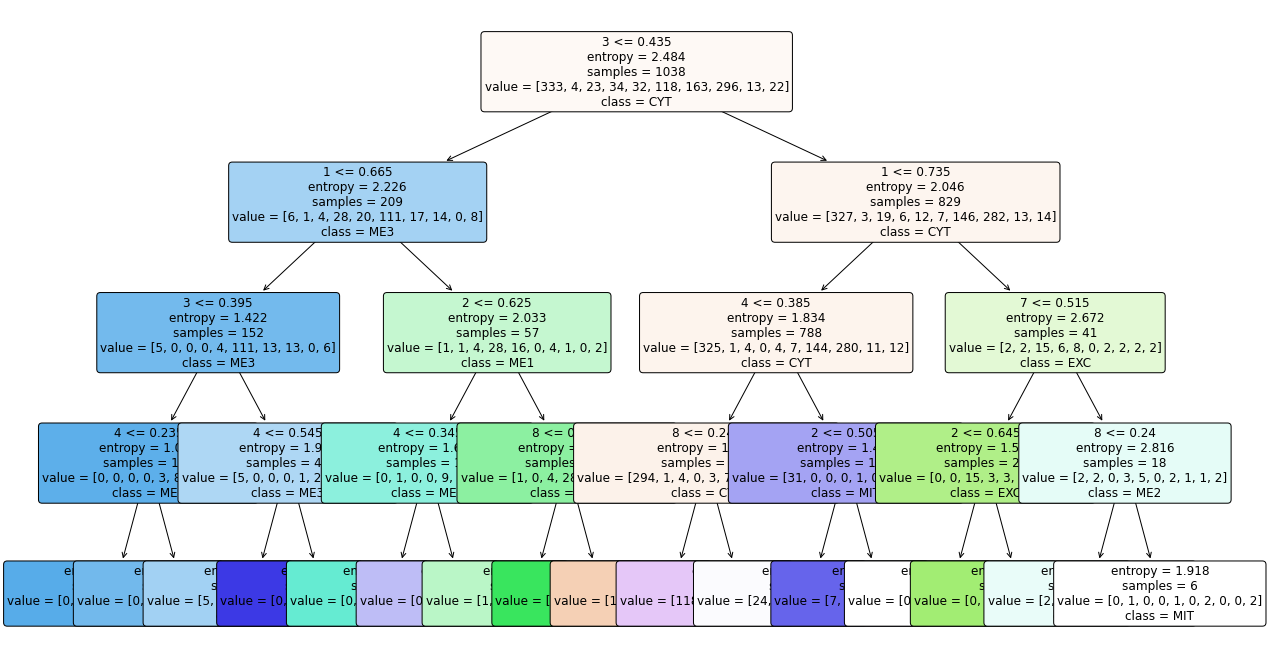

In [10]:
from sklearn import tree
import matplotlib.pyplot as plt

# Ajusta el tamaño de la figura como quieras
plt.figure(figsize=(20, 12))

# featureNames → nombres de columnas
featureNames = data.columns[0:8]

# targetNames → nombres de clases
targetNames = np.unique(y_trainset)

# Dibuja el árbol directamente
tree.plot_tree(
    CellPart, 
    feature_names=featureNames, 
    class_names=targetNames, 
    filled=True,            # colorea las clases
    rounded=True,           # bordes redondeados
    fontsize=12             # tamaño de fuente
)

# Muestra la gráfica
plt.show()